                    Collection of Exploratory Data Analysis 

In [3]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#download dataset to use here 
import requests
download_url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv"
target_csv_path = "nba_all_elo.csv"

response = requests.get(download_url)
response.raise_for_status()
with open(target_csv_path, "wb") as f:
    f.write(response.content)
print("Download ready.")

Download ready.


In [4]:
#read the data and store it as a dataframe
nba= pd.read_csv("nba_all_elo.csv")
type(nba)

pandas.core.frame.DataFrame

In [5]:
#check the size and length of data
len(nba)
nba.shape

(126314, 23)

In [6]:
#explore the first few rows of the data

nba.head()
nba.tail()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,...,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,...,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,...,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,...,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN
126313,63157,201506170CLE,NBA,1,2015,6/16/2015,103,1,GSW,Warriors,...,68.519516,CLE,Cavaliers,97,1700.7391,1692.0859,A,W,0.518550,NaN


                    Getting to Know the Data Up Close 

In [7]:
#columns and data types
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gameorder      126314 non-null  int64  
 1   game_id        126314 non-null  object 
 2   lg_id          126314 non-null  object 
 3   _iscopy        126314 non-null  int64  
 4   year_id        126314 non-null  int64  
 5   date_game      126314 non-null  object 
 6   seasongame     126314 non-null  int64  
 7   is_playoffs    126314 non-null  int64  
 8   team_id        126314 non-null  object 
 9   fran_id        126314 non-null  object 
 10  pts            126314 non-null  int64  
 11  elo_i          126314 non-null  float64
 12  elo_n          126314 non-null  float64
 13  win_equiv      126314 non-null  float64
 14  opp_id         126314 non-null  object 
 15  opp_fran       126314 non-null  object 
 16  opp_pts        126314 non-null  int64  
 17  opp_elo_i      126314 non-nul

In [8]:
#basic descriptive statistics
print(nba.describe())
nba.describe(include = object)

           gameorder        _iscopy        year_id     seasongame  \
count  126314.000000  126314.000000  126314.000000  126314.000000   
mean    31579.000000       0.500000    1988.200374      43.533733   
std     18231.927643       0.500002      17.582309      25.375178   
min         1.000000       0.000000    1947.000000       1.000000   
25%     15790.000000       0.000000    1975.000000      22.000000   
50%     31579.000000       0.500000    1990.000000      43.000000   
75%     47368.000000       1.000000    2003.000000      65.000000   
max     63157.000000       1.000000    2015.000000     108.000000   

         is_playoffs            pts          elo_i          elo_n  \
count  126314.000000  126314.000000  126314.000000  126314.000000   
mean        0.063857     102.729982    1495.236055    1495.236055   
std         0.244499      14.814845     112.139945     112.461687   
min         0.000000       0.000000    1091.644500    1085.774400   
25%         0.000000      93.0000

,game_id,lg_id,date_game,team_id,fran_id,opp_id,opp_fran,game_location,game_result,notes
count,126314,126314,126314,126314,126314,126314,126314,126314,126314,5424
unique,63157,2,12426,104,53,104,53,3,2,231
top,201506170CLE,NBA,4/17/2013,BOS,Lakers,BOS,Lakers,H,L,at New York NY
freq,2,118016,30,5997,6024,5997,6024,63138,63157,440


                    Explore the Data in Depth

In [9]:
#how often specific values occur in a column
nba["team_id"].value_counts()

team_id
BOS    5997
NYK    5769
LAL    5078
DET    4985
PHI    4533
       ... 
PIT      60
INJ      60
TRH      60
DTF      60
SDS      11
Name: count, Length: 104, dtype: int64

In [10]:
nba["fran_id"].value_counts()

fran_id
Lakers          6024
Celtics         5997
Knicks          5769
Warriors        5657
Pistons         5650
Sixers          5644
Hawks           5572
Kings           5475
Wizards         4582
Spurs           4309
Bulls           4307
Pacers          4227
Thunder         4178
Rockets         4154
Nuggets         4120
Nets            4106
Suns            4080
Bucks           4034
Trailblazers    3870
Cavaliers       3810
Clippers        3733
Jazz            3555
Mavericks       3013
Heat            2371
Pelicans        2254
Magic           2207
Timberwolves    2131
Grizzlies       1657
Raptors         1634
Hornets          894
Colonels         846
Squires          799
Spirits          777
Stars            756
Sounds           697
Baltimore        467
Floridians       440
Condors          430
Capitols         291
Olympians        282
Sails            274
Stags            260
Bombers          249
Steamrollers     168
Packers           72
Redskins          65
Rebels            63
Water

In [20]:
nba.loc[nba["fran_id"]== "Lakers", "team_id"].value_counts()

team_id
LAL    5078
MNL     946
Name: count, dtype: int64

In [23]:
# to find out when MNL played their first and last games
nba["date_played"]= pd.to_datetime(nba["date_game"])
nba.loc[nba["team_id"]== "MNL", "date_played"].min()
nba.loc[nba["team_id"]=="MNL", "date_played"].max()
nba.loc[nba["team_id"]=="MNL", "date_played"].agg(("min", "max"))

min   1948-11-04
max   1960-03-26
Name: date_played, dtype: datetime64[ns]

In [11]:
# explore the history of the team with the most points i.e. BOS
nba.loc[nba["team_id"]=="BOS", "pts"].sum()

np.int64(626484)

                    Pandas Series and DataFrames

In [13]:
#series contains a sequence of values and a sequence of indexes (labels, identifiers)
listToSeries = pd.Series([5,7, 30, 56])
print(listToSeries)

0     5
1     7
2    30
3    56
dtype: int64


In [15]:
#commands related to pandas series
print(listToSeries.values)
print(listToSeries.index)
print(type(listToSeries.values))

[ 5  7 30 56]
RangeIndex(start=0, stop=4, step=1)
<class 'numpy.ndarray'>


In [37]:
#a series can have implicit numerical indexes starting from 0. Or we can define specific explicit indexes i.e. labels. 
#This type of series acts as a python dictionary because it has a positional and label index.
friendAges = pd.Series([5, 7, 30, 56, 80], index= ["Kay", "Bobby", "Laila", "Hal", "Bay"])
print(friendAges)

Kay       5
Bobby     7
Laila    30
Hal      56
Bay      80
dtype: int64


In [38]:
#Series from dictionary
friendGender = pd.Series({"Kay": "F", "Bobby" : "M", "Laila": "F", "Hal": "M"})
print(friendGender)
print(friendGender.keys())

Kay      F
Bobby    M
Laila    F
Hal      M
dtype: object
Index(['Kay', 'Bobby', 'Laila', 'Hal'], dtype='object')


In [41]:
#a dataframe is a sequence of series. It allows multiple attributes per key, or multiple columns for each row. So it is a sequence of series that share the same index. 
#combine the two seres above into one dataframe
friendDic = {"Name":[ "Kay", " Bobby", "Laila", "Hal", ], 
            "Ages" : [5,7,30,56, ], 
            "Gender": ["F", "M", "F", "M"]}
friendDf= pd.DataFrame(friendDic)

print(friendDf)
# if you form a dataframe from a dictionary in this case you get implicit indexes. 

     Name  Ages Gender
0     Kay     5      F
1   Bobby     7      M
2   Laila    30      F
3     Hal    56      M


In [43]:
#other way to form a dataframe by combinging two series with labeled indexes. If one series has less observations than the other the missing value will become NaN
friendDf2 = pd.DataFrame({"Ages": friendAges, "Gender" : friendGender})
print(friendDf2)

       Ages Gender
Bay      80    NaN
Bobby     7      M
Hal      56      M
Kay       5      F
Laila    30      F


In [47]:
#commands related to pandas DataFrames
print(friendDf2.values)
print(friendDf2.index)
print(type(friendDf2.values))
print(friendDf2.axes)
print(friendDf2.axes[0])
print(friendDf2.axes[1])
#in dataframes .keys() refers to the columns not indexes
print(friendDf2.keys())

[[80 nan]
 [7 'M']
 [56 'M']
 [5 'F']
 [30 'F']]
Index(['Bay', 'Bobby', 'Hal', 'Kay', 'Laila'], dtype='object')
<class 'numpy.ndarray'>
[Index(['Bay', 'Bobby', 'Hal', 'Kay', 'Laila'], dtype='object'), Index(['Ages', 'Gender'], dtype='object')]
Index(['Bay', 'Bobby', 'Hal', 'Kay', 'Laila'], dtype='object')
Index(['Ages', 'Gender'], dtype='object')
Index(['Ages', 'Gender'], dtype='object')


In [51]:
# use the commands above on the nba dataset
print(nba.axes[0])
print(nba.axes[1])
print(nba.keys())
"kuk" in nba.keys()

RangeIndex(start=0, stop=126314, step=1)
Index(['gameorder', 'game_id', 'lg_id', '_iscopy', 'year_id', 'date_game',
       'seasongame', 'is_playoffs', 'team_id', 'fran_id', 'pts', 'elo_i',
       'elo_n', 'win_equiv', 'opp_id', 'opp_fran', 'opp_pts', 'opp_elo_i',
       'opp_elo_n', 'game_location', 'game_result', 'forecast', 'notes'],
      dtype='object')
Index(['gameorder', 'game_id', 'lg_id', '_iscopy', 'year_id', 'date_game',
       'seasongame', 'is_playoffs', 'team_id', 'fran_id', 'pts', 'elo_i',
       'elo_n', 'win_equiv', 'opp_id', 'opp_fran', 'opp_pts', 'opp_elo_i',
       'opp_elo_n', 'game_location', 'game_result', 'forecast', 'notes'],
      dtype='object')


False

Indexing Operators ([]) and Access Methods .loc and .iloc in Series

In [54]:
#accessing a series element with label index or integer index (the former has not deprecated).
print(friendAges["Kay"])
print(friendAges[0])
print(friendAges[-1])
print(friendAges[2:])

5
5
80
Laila    30
Hal      56
Bay      80
dtype: int64


C:\Users\abalilaj\AppData\Local\Temp\ipykernel_19344\683834977.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(friendAges[0])
C:\Users\abalilaj\AppData\Local\Temp\ipykernel_19344\683834977.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(friendAges[-1])


In [57]:
#acessing series using loc and iloc
colors = pd.Series(['red', 'green', 'purple', 'yellow'], index = [2,4,6,8])
print(colors)
# if we explicitly define label indexes in pandas series thar are integers like above, then when we try to access using positional indexes it becomes confusing. To avoide this we use .loc for label indexes and .iloc for positional indexes
print(colors.loc[2])
print(colors.iloc[2])
#You can use .iloc on a Series similar to using [] on a list.
#You can use .loc on a Series similar to using [] on a dictionary.

2       red
4     green
6    purple
8    yellow
dtype: object
red
purple


Indexing Operators ([]) and Access Methods .loc and .iloc in Data

In [61]:
#indexing operator is used to access columns in dataframes

print(nba['pts'].head())
print(friendDf2.Gender)
type(nba['pts'])

0    66
1    68
2    63
3    47
4    33
Name: pts, dtype: int64
Bay      NaN
Bobby      M
Hal        M
Kay        F
Laila      F
Name: Gender, dtype: object


pandas.core.series.Series

In [67]:
#.loc and iloc are used to access rows in dataframes
print(friendDf2.loc["Kay"])
print(friendDf2.iloc[0])

Ages      5
Gender    F
Name: Kay, dtype: object
Ages       80
Gender    NaN
Name: Bay, dtype: object


In [68]:
print(nba.iloc[-2])

gameorder               63157
game_id          201506170CLE
lg_id                     NBA
_iscopy                     0
year_id                  2015
date_game           6/16/2015
seasongame                102
is_playoffs                 1
team_id                   CLE
fran_id             Cavaliers
pts                        97
elo_i               1700.7391
elo_n               1692.0859
win_equiv           59.290245
opp_id                    GSW
opp_fran             Warriors
opp_pts                   105
opp_elo_i           1813.6349
opp_elo_n           1822.2881
game_location               H
game_result                 L
forecast              0.48145
notes                     NaN
Name: 126312, dtype: object


In [71]:
#loc and iloc can also work with two parameters,the first accesses the row, the second the column. 
print(nba.loc[5555:5559, ["fran_id", "opp_fran", "pts", "opp_pts"]])

      fran_id  opp_fran  pts  opp_pts
5555  Pistons  Warriors   83       56
5556  Celtics    Knicks   95       74
5557   Knicks   Celtics   74       95
5558    Kings    Sixers   81       86
5559   Sixers     Kings   86       81


                            Data Queries

In [76]:
#select nba games afetr year 2010
nba2010 = nba[nba["year_id"] >2010]
nba2010.shape

(12658, 23)

In [78]:
#select games that hava a value other than NaN in the notes variable
nbaNotes= nba[nba["notes"].notnull()]
nbaNotes.shape

(5424, 23)

In [80]:
#use string methods on string data
ers = nba[nba["fran_id"].str.endswith("ers")]
ers.shape

(27797, 23)

In [81]:
#combine multiple criteria to query a dataset using logical operators
nba[(nba["_iscopy"]==0) &
(nba["pts"] > 100) &
(nba["opp_pts"] > 100) &
(nba["team_id"] == "BLB")]

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
1726,864,194902260BLB,NBA,0,1949,2/26/1949,53,0,BLB,Baltimore,...,38.557545,MNL,Lakers,115,1637.9852,1640.4923,H,L,0.338936,NaN
4890,2446,195301100BLB,NBA,0,1953,1/10/1953,32,0,BLB,Baltimore,...,25.797792,BOS,Celtics,105,1591.1434,1563.1652,H,W,0.281855,NaN
4909,2455,195301140BLB,NBA,0,1953,1/14/1953,34,0,BLB,Baltimore,...,24.876236,MNL,Lakers,112,1665.4396,1668.9125,H,L,0.224238,NaN
5208,2605,195303110BLB,NBA,0,1953,3/11/1953,66,0,BLB,Baltimore,...,19.579676,NYK,Knicks,113,1649.1516,1651.4359,H,L,0.178973,at Boston MA
5825,2913,195402220BLB,NBA,0,1954,2/22/1954,60,0,BLB,Baltimore,...,20.736986,BOS,Celtics,111,1591.4943,1593.2749,H,L,0.253365,at Worcester MA


In [85]:
#other combine query
nba[(nba["year_id"]== 1992) &
(nba["team_id"].str.startswith("LA")) &
(nba["_iscopy"]==0) &
(nba["notes"].notnull())]

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
68901,34451,199205030LAC,NBA,0,1992,5/3/1992,86,1,LAC,Clippers,...,47.888252,UTA,Jazz,107,1647.5092,1638.4095,H,W,0.499125,"at Anaheim, CA (Anaheim Convention Center)"
68903,34452,199205030LAL,NBA,0,1992,5/3/1992,86,1,LAL,Lakers,...,39.395412,POR,Trailblazers,102,1655.1210,1670.3677,H,L,0.406874,"at Las Vegas, NV"


Grouping and Aggregating Data

In [87]:
#some descriptive statistics for series 
points = nba["pts"]
print(points.sum())
print(points.max())
print(points.min())
print(points.mean())
print(points.std())

12976235
186
0
102.72998242475101
14.81484465438546


In [89]:
# to group by a variable value and find a descriptive of another variable for each group
nba.groupby("fran_id", sort= False)["pts"].sum()
#so we get the sum of points for each franchise

fran_id
Huskies           3995
Knicks          582497
Stags            20398
Falcons           3797
Capitols         22387
Celtics         626484
Steamrollers     12372
Ironmen           3674
Bombers          17793
Rebels            4474
Warriors        591224
Baltimore        37219
Jets              4482
Pistons         572758
Lakers          637444
Kings           569245
Hawks           567261
Denver            4818
Olympians        22864
Redskins          5372
Waterloo          4921
Packers           6193
Sixers          585891
Wizards         474809
Bulls           437269
Thunder         437735
Squires          91127
Stars            84940
Rockets         432504
Colonels         94435
Pacers          438288
Nuggets         445780
Spurs           453822
Spirits          85874
Sounds           75582
Floridians       49568
Nets            417809
Condors          49642
Bucks           418326
Suns            437486
Clippers        380523
Cavaliers       380416
Trailblazers    402695
Sai

In [91]:
nba.groupby("fran_id", sort=False)["pts"].mean().max()

115.44651162790697

In [92]:
#group by multiple columns
nba[(nba["fran_id"]== "Spurs") &
(nba["year_id"]> 2010)].groupby(["year_id", "game_result"])["game_id"].count()

year_id  game_result
2011     L              25
         W              63
2012     L              20
         W              60
2013     L              30
         W              73
2014     L              27
         W              78
2015     L              31
         W              58
Name: game_id, dtype: int64

In [95]:
#other example of grouping by different columns
nba[(nba["fran_id"] == "Warriors")&
(nba["year_id"]==2015)].groupby(["is_playoffs","game_result"])["game_id"].count()



is_playoffs  game_result
0            L              15
             W              67
1            L               5
             W              16
Name: game_id, dtype: int64

                                    Manipulating Columns


In [97]:
#first always create a copy of the original dataset
nba2= nba.copy()
nba2.shape

(126314, 23)

In [99]:
#create a new column using existing columns
nba2["difference"] = nba2["pts"]- nba2["opp_pts"]
nba2["difference"].max()

68

In [106]:
#rename columns
nba2.rename(columns= {"game_result":"result", "game_location":"location"}, inplace = True)
nba2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 24 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   gameorder    126314 non-null  int64  
 1   game_id      126314 non-null  object 
 2   lg_id        126314 non-null  object 
 3   _iscopy      126314 non-null  int64  
 4   year_id      126314 non-null  int64  
 5   date_game    126314 non-null  object 
 6   seasongame   126314 non-null  int64  
 7   is_playoffs  126314 non-null  int64  
 8   team_id      126314 non-null  object 
 9   fran_id      126314 non-null  object 
 10  pts          126314 non-null  int64  
 11  elo_i        126314 non-null  float64
 12  elo_n        126314 non-null  float64
 13  win_equiv    126314 non-null  float64
 14  opp_id       126314 non-null  object 
 15  opp_fran     126314 non-null  object 
 16  opp_pts      126314 non-null  int64  
 17  opp_elo_i    126314 non-null  float64
 18  opp_elo_n    126314 non-

In [108]:
#dropping unneeded columns
nba2.shape
elo_columns = ["elo_i", "elo_n", "opp_elo_i", "opp_elo_n"]
nba2.drop(elo_columns, inplace = True, axis = 1)
nba2.shape

(126314, 20)

                                    Specyfing Data Types 

In [113]:
#to check automatic datatypes
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gameorder      126314 non-null  int64  
 1   game_id        126314 non-null  object 
 2   lg_id          126314 non-null  object 
 3   _iscopy        126314 non-null  int64  
 4   year_id        126314 non-null  int64  
 5   date_game      126314 non-null  object 
 6   seasongame     126314 non-null  int64  
 7   is_playoffs    126314 non-null  int64  
 8   team_id        126314 non-null  object 
 9   fran_id        126314 non-null  object 
 10  pts            126314 non-null  int64  
 11  elo_i          126314 non-null  float64
 12  elo_n          126314 non-null  float64
 13  win_equiv      126314 non-null  float64
 14  opp_id         126314 non-null  object 
 15  opp_fran       126314 non-null  object 
 16  opp_pts        126314 non-null  int64  
 17  opp_elo_i      126314 non-nul

In [116]:
#convert a vraiable from object to date 
nba["date_game"] = pd.to_datetime(nba["date_game"])
print(nba["date_game"].head(3))


0   1946-11-01
1   1946-11-01
2   1946-11-02
Name: date_game, dtype: datetime64[ns]


In [118]:
nba["game_location"].nunique()
nba["game_location"].value_counts()

game_location
H    63138
A    63138
N       38
Name: count, dtype: int64

In [120]:
# transform an object data colum into a categorical one
nba["game_location"] = pd.Categorical(nba["game_location"])
nba["game_location"].dtype

CategoricalDtype(categories=['A', 'H', 'N'], ordered=False, categories_dtype=object)

In [125]:
#transform another variable
nba["game_result"].nunique()
nba["game_result"].value_counts()
nba["game_result"]= pd.Categorical(nba["game_result"])
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   gameorder      126314 non-null  int64         
 1   game_id        126314 non-null  object        
 2   lg_id          126314 non-null  object        
 3   _iscopy        126314 non-null  int64         
 4   year_id        126314 non-null  int64         
 5   date_game      126314 non-null  datetime64[ns]
 6   seasongame     126314 non-null  int64         
 7   is_playoffs    126314 non-null  int64         
 8   team_id        126314 non-null  object        
 9   fran_id        126314 non-null  object        
 10  pts            126314 non-null  int64         
 11  elo_i          126314 non-null  float64       
 12  elo_n          126314 non-null  float64       
 13  win_equiv      126314 non-null  float64       
 14  opp_id         126314 non-null  object        
 15  

                                    Cleaning Data

In [126]:
# to drop all rows that have missing values in any column
small= nba.dropna()
small.shape

(5424, 23)

In [129]:
#to drop columns with missing values in any row
large = nba.dropna(axis=1)
large.shape

(126314, 22)

In [136]:
#to replace missing values with a default like 99, or a string 
nba3= nba.copy()
nba3["notes"].fillna(
    value= "no note",
    inplace = True
) 

nba3["notes"]. describe()

C:\Users\abalilaj\AppData\Local\Temp\ipykernel_19344\195871125.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nba3["notes"].fillna(


count      126314
unique        232
top       no note
freq       120890
Name: notes, dtype: object

In [137]:
# inspect the dataset to detect invalid values
nba.describe()

,gameorder,_iscopy,year_id,date_game,seasongame,is_playoffs,pts,elo_i,elo_n,win_equiv,opp_pts,opp_elo_i,opp_elo_n,forecast
count,126314.000000,126314.000000,126314.000000,126314,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000
mean,31579.000000,0.500000,1988.200374,1988-04-09 00:53:18.429311104,43.533733,0.063857,102.729982,1495.236055,1495.236055,41.707889,102.729982,1495.236055,1495.236055,0.500000
min,1.000000,0.000000,1947.000000,1946-11-01 00:00:00,1.000000,0.000000,0.000000,1091.644500,1085.774400,10.152501,0.000000,1091.644500,1085.774400,0.020447
25%,15790.000000,0.000000,1975.000000,1974-11-08 00:00:00,22.000000,0.000000,93.000000,1417.237975,1416.994900,34.103035,93.000000,1417.237975,1416.994900,0.327989
50%,31579.000000,0.500000,1990.000000,1990-02-06 00:00:00,43.000000,0.000000,103.000000,1500.945550,1500.954400,42.113357,103.000000,1500.945550,1500.954400,0.500000
75%,47368.000000,1.000000,2003.000000,2003-03-19 00:00:00,65.000000,0.000000,112.000000,1576.060000,1576.291625,49.635328,112.000000,1576.060000,1576.291625,0.672011
max,63157.000000,1.000000,2015.000000,2015-06-16 00:00:00,108.000000,1.000000,186.000000,1853.104500,1853.104500,71.112038,186.000000,1853.104500,1853.104500,0.979553
std,18231.927643,0.500002,17.582309,NaN,25.375178,0.244499,14.814845,112.139945,112.461687,10.627332,14.814845,112.139945,112.461687,0.215252


In [139]:
# turns out minimum for points "pts"is 0. How can this be? 
nba[nba["pts"]== 0]

# this game was forefeited that is why points is 0

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
26684,13343,197210260VIR,ABA,1,1973,1972-10-26,7,0,DNR,Nuggets,...,40.408863,VIR,Squires,2,1484.1907,1487.083,A,L,0.328948,at Richmond VA; forfeit to VIR


In [140]:
# using logic operators to identify inconsistent values
nba[(nba["pts"] > nba["opp_pts"]) & (nba["game_result"] != "W")].empty
nba[(nba["pts"]< nba["opp_pts"]) & (nba["game_result"] != "L")]. empty

True

Combinde two Dataframes

In [142]:
#create a new dataframe to combine with the existing one above
moreFriend = pd.DataFrame(
    {"Ages": [35, 70], "Gender": ["M", "F"]}, 
    index = ["Loli", "Bela"]
)

In [143]:
#combine dataframes using .concat()
allFriends= pd.concat([friendDf2, moreFriend], sort= False)
allFriends

,Ages,Gender
Bay,80,NaN
Bobby,7,M
Hal,56,M
Kay,5,F
Laila,30,F
Loli,35,M
Bela,70,F


In [150]:
# we cna also concat with new columns instead of new rows
friendMoneyLoc= pd.DataFrame({"money": [50,58,69, 50, 6, 9],
                            "location": ["Tirana", "Italy", "Bosnia", "Atlanta", "Berlin", "Kuc"]}, 
                            index = ["Bobby", "Hal", "Kay", "Laila", "Loli", "Bela"]
    
)

otherFr= pd.concat([allFriends, friendMoneyLoc], axis = 1, sort= False, join = "inner" )
otherFr

,Ages,Gender,money,location
Bobby,7,M,50,Tirana
Hal,56,M,58,Italy
Kay,5,F,69,Bosnia
Laila,30,F,50,Atlanta
Loli,35,M,6,Berlin
Bela,70,F,9,Kuc


In [154]:
# to combine dataframews using the merge() function
moreFriendInfo = pd.DataFrame({"village": ["brataj", "gjorm", "kot", "vranisht", "kallarat"], 
                              "year": [1895, 1985, 1467, 1874, 1840]}, 
                             index=["Italy", "Bosnia", "Atlanta", "Berlin", "Kuc"])
updatedFriends= pd.merge(otherFr, moreFriendInfo, left_on= "location", right_index= True, how = "left")
updatedFriends

,Ages,Gender,money,location,village,year
Bobby,7,M,50,Tirana,NaN,NaN
Hal,56,M,58,Italy,brataj,1895.0
Kay,5,F,69,Bosnia,gjorm,1985.0
Laila,30,F,50,Atlanta,kot,1467.0
Loli,35,M,6,Berlin,vranisht,1874.0
Bela,70,F,9,Kuc,kallarat,1840.0


                Simple Data Visualization 

In [155]:
 import matplotlib.pyplot as plt

<Axes: xlabel='year_id'>

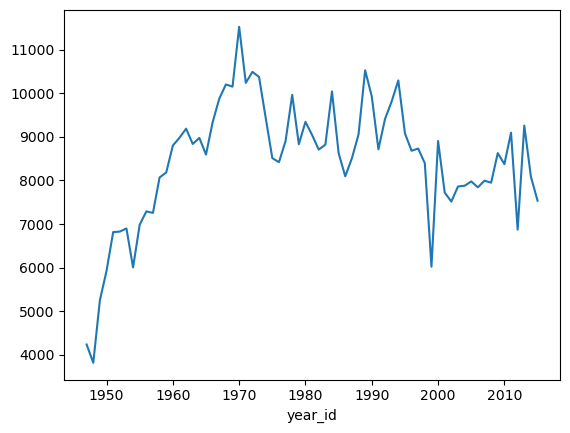

In [156]:
nba[nba["fran_id"] == "Knicks"].groupby("year_id")["pts"].sum().plot()

<Axes: xlabel='fran_id'>

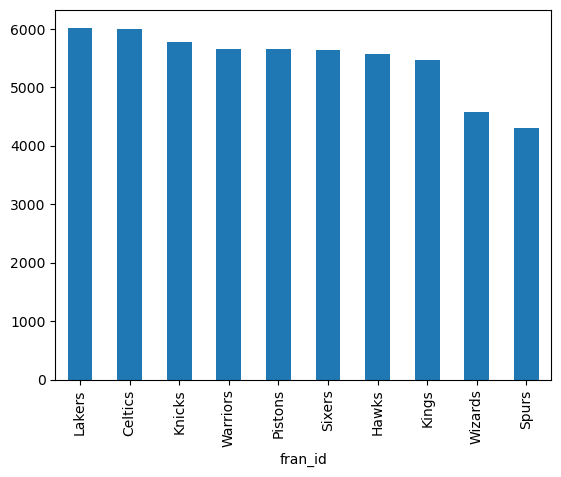

In [157]:
nba["fran_id"].value_counts().head(10).plot(kind= "bar")

<Axes: ylabel='count'>

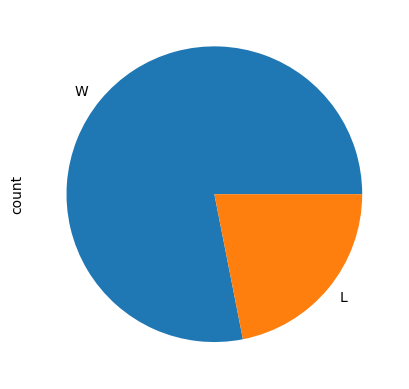

In [158]:
nba[(nba["fran_id"]=="Heat") &
(nba["year_id"]== 2013)
]["game_result"]. value_counts().plot(kind= "pie")